# Análise de Medalhas por Países

Este notebook realiza uma análise das medalhas olímpicas por país, separando por tipo de olimpíada (Verão, Inverno e Geral) e gera gráficos dos 50 países com mais medalhas. Abaixo está o resumo do que cada célula faz:

1. **Importação do pandas**
   - Importa a biblioteca pandas para manipulação de dados.

In [ ]:
import pandas as pd

2. **Leitura do arquivo de medalhas**
   - Lê o arquivo CSV com os dados de medalhas e exibe o DataFrame.

In [ ]:
df = pd.read_csv('../../bronze/medalhas_1986_2024.csv')
df

,edition,country_noc,bronze,gold,silver,total
0,2024 Summer Olympics,USA,95,134,101,330
1,1904 Summer Olympics,USA,80,79,85,244
2,1980 Summer Olympics,RUS,46,80,69,195
3,2024 Summer Olympics,FRA,39,53,95,187
4,1984 Summer Olympics,USA,30,82,61,173
...,...,...,...,...,...,...
1876,2004 Summer Olympics,HKG,0,0,1,1
1877,2002 Winter Olympics,SLO,1,0,0,1
1878,2004 Summer Olympics,CMR,0,1,0,1
1879,2004 Summer Olympics,ERI,1,0,0,1


3. **Criação da coluna 'Tipo'**
   - Adiciona uma coluna indicando se a edição é de Verão ou Inverno, baseada na coluna 'edition'.

In [ ]:
df['Tipo'] = df['edition'].apply(
    lambda x: 'Verão' if 'Summer' in x else 'Inverno'
)

4. **Agrupamento por país e tipo**
   - Agrupa os dados por país e tipo de olimpíada, somando as medalhas de ouro, prata e bronze.

In [ ]:
df_group = df.groupby(['country_noc', 'Tipo'])[
    ['gold', 'silver', 'bronze']
].sum().reset_index()

5. **Cálculo do total de medalhas por grupo**
   - Cria uma coluna com o total de medalhas (ouro + prata + bronze) para cada grupo.

In [ ]:
df_group['total'] = df_group[['gold', 'silver', 'bronze']].sum(axis=1)

6. **Cálculo do total geral por país**
   - Agrupa por país, soma todas as medalhas e marca o tipo como 'Geral'.

In [ ]:
df_total = df.groupby('country_noc')[
    ['gold', 'silver', 'bronze']
].sum().reset_index()

df_total['total'] = df_total[['gold','silver','bronze']].sum(axis=1)
df_total['Tipo'] = 'Geral'

7. **Concatenação dos DataFrames**
   - Junta os dados agrupados por tipo e o total geral em um único DataFrame e exibe o resultado.

In [ ]:
df_final = pd.concat([df_group, df_total], ignore_index=True)
df_final

,country_noc,Tipo,gold,silver,bronze,total
0,AFG,Verão,0,0,2,2
1,AHO,Verão,0,1,0,1
2,AIN,Verão,1,4,1,6
3,ALB,Verão,0,0,2,2
4,ALG,Verão,7,4,9,20
...,...,...,...,...,...,...
357,VIE,Geral,1,3,1,5
358,WIF,Geral,0,0,2,2
359,YUG,Geral,26,32,29,87
360,ZAM,Geral,0,1,2,3


8. **Salvamento do resumo em CSV**
   - Salva o DataFrame final em um arquivo CSV para uso posterior.

In [ ]:
df_final.to_csv('../analise_medalhas/medalhas_summary.csv', index=False)

9. **Importação de bibliotecas para gráficos**
   - Importa matplotlib, numpy e os para geração e salvamento dos gráficos.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

10. **Função de plot dos top 50 países**
    - Define uma função para gerar gráficos de barras horizontais dos 50 países com mais medalhas, separando por tipo e salvando as imagens.

In [ ]:
def plot_top50_medalhas(df, tipo, titulo, nome_arquivo):
 
    os.makedirs("../analise_medalhas", exist_ok=True)

    data = df[df['Tipo'] == tipo].copy()
    data = data.sort_values(by='total', ascending=False).head(50)
    data = data.sort_values(by='total', ascending=True)

    y = np.arange(len(data))

    plt.figure(figsize=(12, 14))

    plt.barh(y, data['gold'], color='#d4af37', label='Ouro')
    plt.barh(y, data['silver'], left=data['gold'], color='#c0c0c0', label='Prata')
    plt.barh(y, data['bronze'], left=data['gold'] + data['silver'], color='#cd7f32', label='Bronze')

    plt.yticks(y, data['country_noc'])

    plt.margins(y=0)
    plt.ylim(-0.5, len(data) - 0.5)

    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.xlabel('Total de Medalhas')
    plt.ylabel('País (NOC)')

    plt.legend(title="Medalhas")
    plt.tight_layout()

    caminho = f"../analise_medalhas/{nome_arquivo}"
    plt.savefig(caminho, dpi=300, bbox_inches='tight')

    plt.show()

11. **Geração dos gráficos**
    - Chama a função para gerar e salvar os gráficos dos top 50 países no geral, verão e inverno.

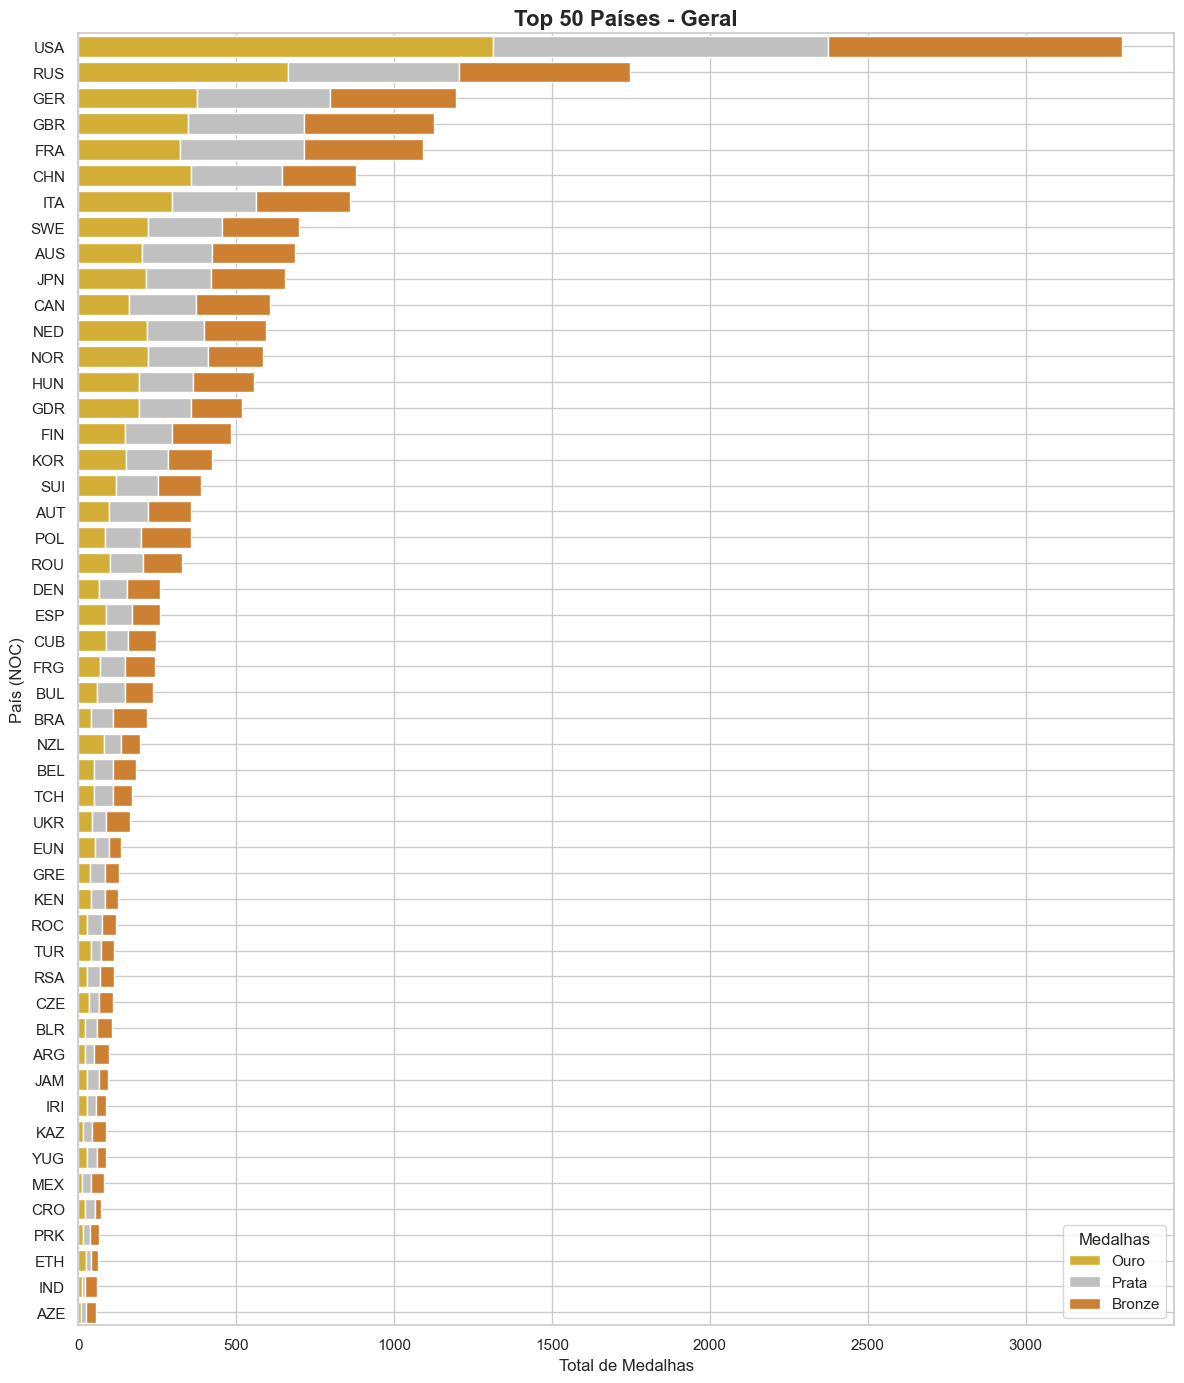

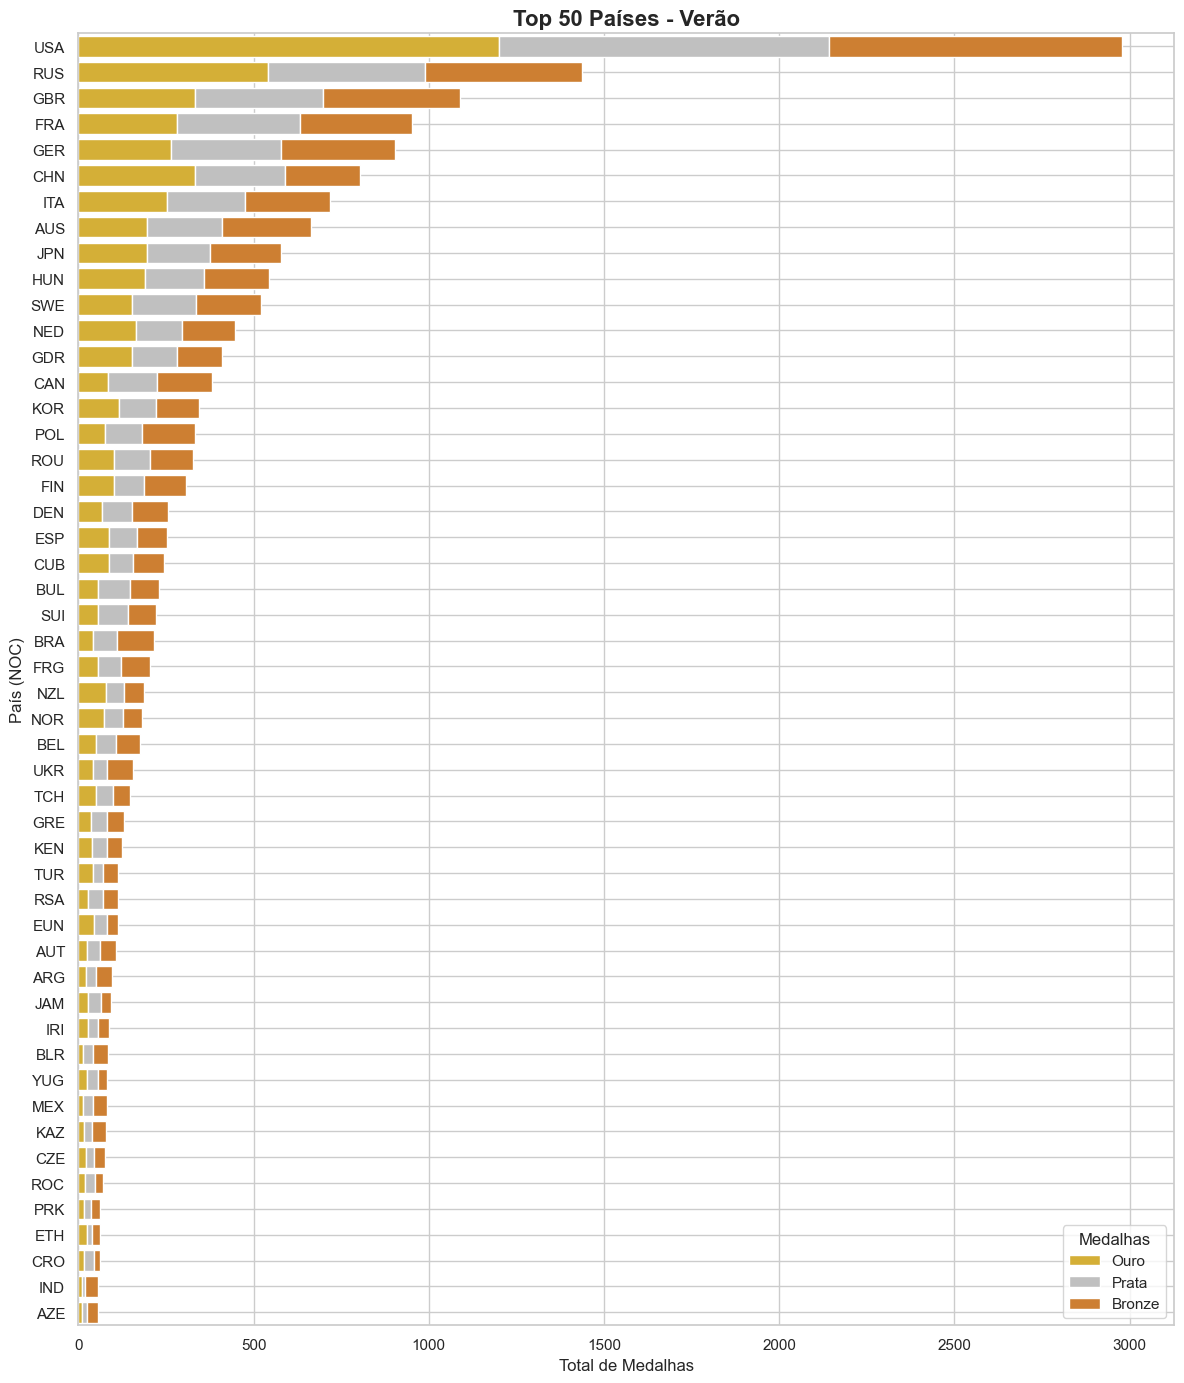

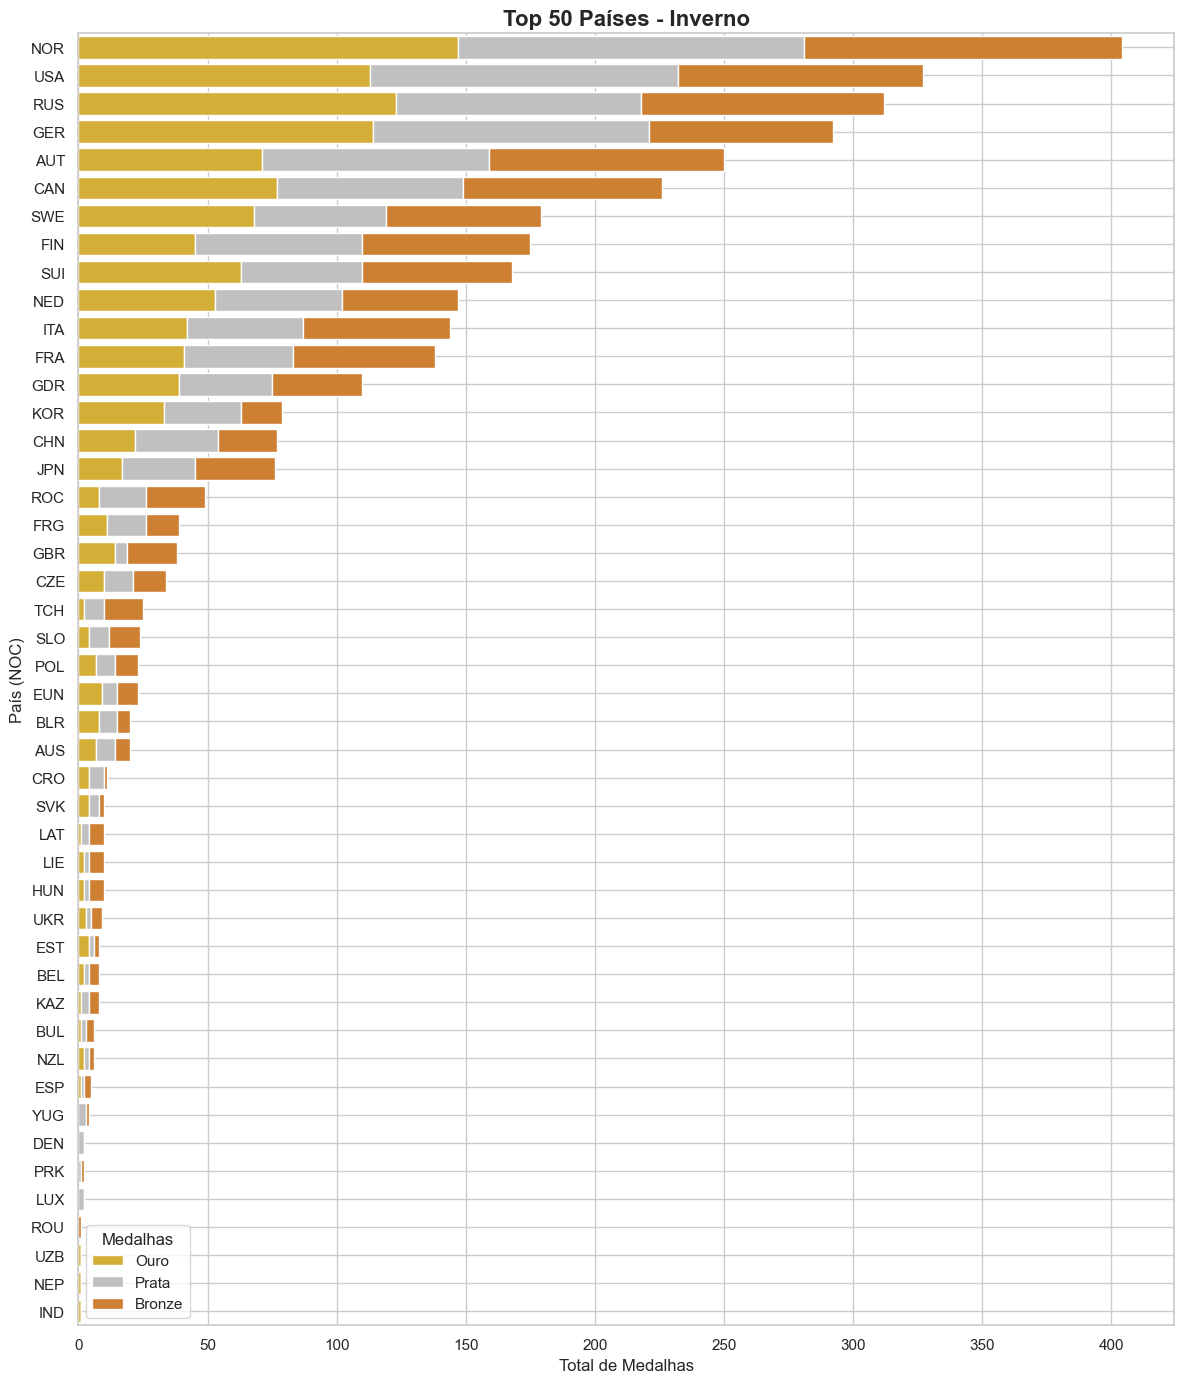

In [ ]:
plot_top50_medalhas(
    df_final, 
    'Geral', 
    'Top 50 Países - Geral', 
    'medalhas_geral.png'
)

plot_top50_medalhas(
    df_final, 
    'Verão', 
    'Top 50 Países - Verão', 
    'medalhas_verao.png'
)

plot_top50_medalhas(
    df_final, 
    'Inverno', 
    'Top 50 Países - Inverno', 
    'medalhas_inverno.png'
)